# Planificación de intervalos con pesos

Ecuación de Bellman: **OPT(j) = max(w_j + OPT(p(j)), OPT(j−1))**, donde p(j) es el último trabajo que termina antes de que empiece j.

In [1]:
import math
import random
import sys
import time
from bisect import bisect_right

import matplotlib.pyplot as plt

sys.setrecursionlimit(10_000)

## Datos

In [2]:
ujobs = [
    #nombre, peso, inicio, fin
    ("J1", 5, 1, 4),
    ("J2", 8, 3, 5),
    ("J3", 3, 0, 6),
    ("J4", 10, 4, 7),
    ("J5", 6, 3, 8),
    ("J6", 4, 5, 9),
    ("J7", 9, 6, 10),
    ("J8", 7, 4, 11),
]


def generateJobs(n=8, max_time=18, max_weight=10, min_duration=1, max_duration=7, seed=None):
    rng = random.Random(seed)
    intervals = []
    for _ in range(n):
        duration = rng.randint(min_duration, max_duration)
        start = rng.randint(0, max_time - duration)
        weight = rng.randint(1, max_weight)
        intervals.append((weight, start, start + duration))
    # Se nombran los trabajos después de ordenarlos por tiempo de fin, así J1 termina primero y Jn al último
    intervals.sort(key=lambda job: (job[2], job[1]))
    return [(f"J{i}", weight, start, finish) for i, (weight, start, finish) in enumerate(intervals, 1)]


SORTED_BY_FINISH_ASC = sorted(ujobs, key=lambda job: job[3])

## Planificación óptima

In [3]:
def computeP(jobs=SORTED_BY_FINISH_ASC):
    # p[j] = cuántos trabajos terminan antes de que empiece j (búsqueda binaria, O(n log n))
    finishes = [job[3] for job in jobs]
    p = [0] * (len(jobs) + 1)
    for j in range(1, len(jobs) + 1):
        p[j] = bisect_right(finishes, jobs[j - 1][2])
    return p


def bruteForceCalls(p):
    # Llamadas que haría la fuerza bruta: T(0) = 1, T(j) = 1 + T(p(j)) + T(j - 1)
    T = [1] * len(p)
    for j in range(1, len(p)):
        T[j] = 1 + T[p[j]] + T[j - 1]
    return T[-1]


def formatLog10(value_log10, decimals=3):
    # Muestra 10^value_log10 de forma legible, aunque sea demasiado grande para un float
    if value_log10 < 6:
        return f"{10 ** value_log10:,.{decimals}f}"
    return f"{10 ** (value_log10 % 1):.1f}×10^{int(value_log10)}"


def formatDuration(ms_log10):
    # Pasa 10^ms_log10 milisegundos a la unidad más grande que quede >= 1 (ms, s, min, h o días)
    units = (("días", 86_400_000), ("h", 3_600_000), ("min", 60_000), ("s", 1_000))
    for unit, ms in units:
        if ms_log10 >= math.log10(ms):
            return f"{formatLog10(ms_log10 - math.log10(ms), 1)} {unit}"
    return f"{formatLog10(ms_log10, 3 if ms_log10 < 0 else 1)} ms"


def bestSchedule(jobs=SORTED_BY_FINISH_ASC):
    n = len(jobs)
    p = computeP(jobs)

    M = [0] * (n + 1)
    for j in range(1, n + 1):
        weight = jobs[j - 1][1]
        M[j] = max(weight + M[p[j]], M[j - 1])

    chosen = []
    j = n
    while j > 0:
        if jobs[j - 1][1] + M[p[j]] >= M[j - 1]:
            chosen.append(jobs[j - 1][0])
            j = p[j]
        else:
            j -= 1

    return M[n], list(reversed(chosen))

## Fuerza bruta vs memoizado

In [4]:
BRUTE_CALL_LIMIT = 2_000_000  # una ejecución de fuerza bruta se aborta después de estas llamadas


class TooManyCalls(Exception):
    pass


def optBruteForce(j, jobs, p, calls, limit=BRUTE_CALL_LIMIT):
    calls[0] += 1
    if calls[0] > limit:
        raise TooManyCalls
    if j == 0:
        return 0
    # tomar el trabajo j o no tomarlo
    return max(jobs[j - 1][1] + optBruteForce(p[j], jobs, p, calls, limit),
               optBruteForce(j - 1, jobs, p, calls, limit))


def optMemoized(j, jobs, p, memo, calls):
    calls[0] += 1
    if j == 0:
        return 0
    if memo[j] is None:
        memo[j] = max(jobs[j - 1][1] + optMemoized(p[j], jobs, p, memo, calls),  # tomar j
                      optMemoized(j - 1, jobs, p, memo, calls))  # no tomar j
    return memo[j]


def runBruteForce(jobs, p, limit=BRUTE_CALL_LIMIT):
    calls = [0]
    t0 = time.perf_counter()
    try:
        value = optBruteForce(len(jobs), jobs, p, calls, limit)
    except TooManyCalls:
        return None
    return value, calls[0], time.perf_counter() - t0


def runMemoized(jobs, p):
    calls = [0]
    memo = [None] * (len(jobs) + 1)
    t0 = time.perf_counter()
    value = optMemoized(len(jobs), jobs, p, memo, calls)
    return value, calls[0], time.perf_counter() - t0


def compare(ns, seed=0, limit=BRUTE_CALL_LIMIT):
    rows = []
    brute_enabled = True
    for n in ns:
        jobs = generateJobs(n=n, max_time=max(18, n), seed=seed)
        p = computeP(jobs)

        memo_value, memo_calls, memo_time = runMemoized(jobs, p)

        brute_calls = brute_time = None
        if brute_enabled:
            result = runBruteForce(jobs, p, limit)
            if result is None:
                brute_enabled = False
            else:
                brute_value, brute_calls, brute_time = result
                assert brute_value == memo_value, f"los resultados difieren para n={n}"

        rows.append((n, brute_calls, brute_time, memo_calls, memo_time))
    return rows

## Árbol de recursión

In [5]:
class JobNode:
    def __init__(self, j, name, weight):
        self.j = j            # posición 1..n, 0 = ya no quedan trabajos
        self.name = name
        self.weight = weight
        self.take = None      # hijo izquierdo: OPT(p(j)), se toma el trabajo j
        self.skip = None      # hijo derecho:   OPT(j - 1), se omite el trabajo j
        self.value = 0        # OPT(j)
        self.took = False


def buildJobTree(jobs=SORTED_BY_FINISH_ASC, j=None, p=None):
    if p is None:
        p = computeP(jobs)
    if j is None:
        j = len(jobs)
    if j == 0:
        return JobNode(0, "∅", 0)

    name, weight, _, _ = jobs[j - 1]
    node = JobNode(j, name, weight)
    node.take = buildJobTree(jobs, p[j], p)
    node.skip = buildJobTree(jobs, j - 1, p)
    take_value = weight + node.take.value
    node.took = take_value >= node.skip.value
    node.value = max(take_value, node.skip.value)
    return node


def countNodes(node):
    if node is None:
        return 0
    return 1 + countNodes(node.take) + countNodes(node.skip)


TREE_NODE_LIMIT = 80  # con más nodos no se puede leer, los niveles más profundos se cortan


def fitDepth(root, limit=TREE_NODE_LIMIT):
    counts = []  # counts[d] = número de nodos en la profundidad d
    stack = [(root, 0)]
    while stack:
        node, depth = stack.pop()
        if depth == len(counts):
            counts.append(0)
        counts[depth] += 1
        if node.j:
            stack.append((node.take, depth + 1))
            stack.append((node.skip, depth + 1))
    shown, depth = 0, -1
    while depth + 1 < len(counts) and shown + counts[depth + 1] <= limit:
        depth += 1
        shown += counts[depth]
    return depth, len(counts) - 1

## Gráficas

In [6]:
BAR_LIMIT = 40  # con más trabajos que esto se dibujan líneas delgadas en vez de barras con etiqueta


def plotJobs(jobs=SORTED_BY_FINISH_ASC, chosen=(), show=True, elapsed_ms=None, expected_brute=None):
    chosen = set(chosen)
    names = [job_data[0] for job_data in jobs]
    weights = [job_data[1] for job_data in jobs]
    max_weight = max(weights)
    fig, ax = plt.subplots(figsize=(10, 6))

    if len(jobs) <= BAR_LIMIT:
        # Dibuja barras horizontales
        for i, job_data in enumerate(reversed(jobs)):
            name, weight, start, finish = job_data
            color = plt.cm.viridis(weight / max_weight)
            if name in chosen:
                # Planificación óptima: con achurado y borde grueso
                ax.barh(y=i, width=finish - start, left=start, color=color, edgecolor='black',
                        linewidth=2.5, hatch='//')
            else:
                ax.barh(y=i, width=finish - start, left=start, color=color, edgecolor='black')
            ax.text(start + (finish - start) / 2, i, f"{name} (w={weight})", ha='center', va='center', fontsize=10)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(list(reversed(names)))
    else:
        # Demasiados trabajos para barras: una línea delgada por trabajo, coloreada según su peso
        rows = list(reversed(jobs))
        ys = range(len(rows))
        ax.hlines(y=ys, xmin=[j[2] for j in rows], xmax=[j[3] for j in rows],
                  colors=[plt.cm.viridis(j[1] / max_weight) for j in rows], linewidth=1)
        # Planificación óptima como líneas negras gruesas
        chosen_rows = [(i, j) for i, j in enumerate(rows) if j[0] in chosen]
        if chosen_rows:
            ax.hlines(y=[i for i, _ in chosen_rows], xmin=[j[2] for _, j in chosen_rows],
                      xmax=[j[3] for _, j in chosen_rows], colors="black", linewidth=3, zorder=2,
                      label=f"Planificación óptima ({len(chosen_rows)} trabajos)")
        if chosen_rows:
            ax.legend(loc="upper right")
        ax.set_ylim(-1, len(rows))
        ax.set_yticks([])
        fig.colorbar(plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, max_weight)),
                     ax=ax, label="Peso")

    # Etiquetas y título
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Trabajo")
    title = f"Trabajos (n={len(jobs)})"
    if chosen:
        total = sum(job_data[1] for job_data in jobs if job_data[0] in chosen)
        title += f" — peso óptimo {total}"
    if elapsed_ms is not None:
        title += f" — ejecución {elapsed_ms:.1f} ms"
    if expected_brute is not None:
        title += f"\nfuerza bruta esperada ≈ {expected_brute}"
    ax.set_title(title)
    max_finish = max(18, max(job_data[3] for job_data in jobs))
    ax.set_xlim(0, max_finish + 1)
    # Líneas guía para comparar tiempos más fácil (máximo ~20 marcas)
    ax.set_xticks(range(0, max_finish + 1, max(1, max_finish // 20)))
    ax.grid(axis='x', linestyle='--', alpha=0.6, color='gray')
    ax.set_axisbelow(True)

    plt.tight_layout()
    if show:
        plt.show()


def plotJobTree(root, max_depth=None, show=True):
    total = countNodes(root)
    fit, full_depth = fitDepth(root)
    if max_depth is None:
        max_depth = fit
    cut = max_depth < full_depth

    # Cuántas veces se calcula cada subproblema OPT(j) en el árbol completo
    seen = {}

    def countCalls(node):
        seen[node.j] = seen.get(node.j, 0) + 1
        if node.j:
            countCalls(node.take)
            countCalls(node.skip)

    countCalls(root)

    # Las hojas reciben posiciones x consecutivas, los padres quedan centrados sobre sus hijos
    positions = {}
    next_x = [0]

    def layout(node, depth):
        if node.j == 0 or depth == max_depth:
            positions[id(node)] = (next_x[0], -depth)
            next_x[0] += 1
            return
        layout(node.take, depth + 1)
        layout(node.skip, depth + 1)
        x = (positions[id(node.take)][0] + positions[id(node.skip)][0]) / 2
        positions[id(node)] = (x, -depth)

    layout(root, 0)

    width = min(30, max(10, next_x[0] * 0.7))
    height = min(14, max(6, (max_depth + 1) * 1.1))
    fig, ax = plt.subplots(figsize=(width, height))
    fig.canvas.manager.set_window_title("Árbol de recursión")
    font = 10 if next_x[0] < 30 else 8

    def draw(node, depth, on_best_path):
        x, y = positions[id(node)]
        truncated = node.j and depth == max_depth
        if node.j and not truncated:
            for child, is_take in ((node.take, True), (node.skip, False)):
                cx, cy = positions[id(child)]
                best = on_best_path and node.took == is_take
                ax.plot([x, cx], [y, cy], color="red" if best else "gray",
                        linewidth=2.5 if best else 1, zorder=1)
                ax.text((x + cx) / 2, (y + cy) / 2, f"+{node.weight}" if is_take else "omitir",
                        fontsize=font - 1, ha="center", va="center", color="dimgray",
                        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none"))
                draw(child, depth + 1, best)

        if node.j == 0:
            label, color = "0", "lightgray"
        else:
            label = f"{node.name}\n{node.value}" + ("\n…" if truncated else "")
            color = "orange" if seen[node.j] > 1 else "lightblue"
        ax.text(x, y, label, ha="center", va="center", fontsize=font, zorder=2,
                bbox=dict(boxstyle="circle", fc=color, ec="red" if on_best_path else "black",
                          linewidth=2 if on_best_path else 1, linestyle="--" if truncated else "-"))

    draw(root, 0, True)

    repeated = sum(count - 1 for j, count in seen.items() if j and count > 1)
    title = f"Árbol de recursión de OPT({root.j}) — {total} llamadas, {repeated} repetidas"
    if cut:
        title += f" (mostrando profundidad {max_depth} de {full_depth}, los nodos punteados continúan)"
    ax.set_title(title + "\nnaranja = subproblema calculado más de una vez, "
                 "camino rojo = decisiones óptimas, +w = tomar trabajo, omitir = omitir trabajo")
    ax.axis("off")
    plt.tight_layout()
    if show:
        plt.show()


def printTable(rows):
    print(f"{'n':>5} | {'llam. bruta':>12} {'tiempo bruta':>12} | {'llam. memo':>10} {'tiem. memo':>10} | aceleración")
    print("-" * 72)
    for n, b_calls, b_time, m_calls, m_time in rows:
        if b_calls is None:
            brute = f"{'—':>12} {'muy lento':>12}"
            speedup = ""
        else:
            brute = f"{b_calls:>12,} {b_time * 1000:>10.2f}ms"
            speedup = f"{b_time / m_time:>8.0f}x" if m_time else ""
        print(f"{n:>5} | {brute} | {m_calls:>10,} {m_time * 1000:>8.3f}ms | {speedup}")


def plotComparison(rows, show=True):
    ns = [r[0] for r in rows]
    brute = [r for r in rows if r[1] is not None]

    fig, (ax_calls, ax_time) = plt.subplots(1, 2, figsize=(13, 5))
    fig.canvas.manager.set_window_title("Fuerza bruta vs memoizado")

    ax_calls.plot([r[0] for r in brute], [r[1] for r in brute], "o-", color="tab:red", label="Fuerza bruta")
    ax_calls.plot(ns, [r[3] for r in rows], "o-", color="tab:blue", label="Memoizado")
    ax_calls.set_yscale("log")
    ax_calls.set_xlabel("n (trabajos)")
    ax_calls.set_ylabel("llamadas a OPT (escala log)")
    ax_calls.set_title("Número de llamadas")

    ax_time.plot([r[0] for r in brute], [r[2] * 1000 for r in brute], "o-", color="tab:red", label="Fuerza bruta")
    ax_time.plot(ns, [r[4] * 1000 for r in rows], "o-", color="tab:blue", label="Memoizado")
    ax_time.set_yscale("log")
    ax_time.set_xlabel("n (trabajos)")
    ax_time.set_ylabel("tiempo en ms (escala log)")
    ax_time.set_title("Tiempo de ejecución")

    for ax in (ax_calls, ax_time):
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        ax.legend()
        if len(brute) < len(rows):
            ax.axvline(brute[-1][0], color="tab:red", linestyle=":", alpha=0.6)
            ax.text(brute[-1][0], ax.get_ylim()[1], " fuerza bruta detenida", color="tab:red",
                    va="top", fontsize=9)

    fig.suptitle("OPT(j) = max(w_j + OPT(p(j)), OPT(j-1)): fuerza bruta es exponencial, memoizado es lineal")
    plt.tight_layout()
    if show:
        plt.show()

---
# Ejemplos

## 8 trabajos

peso óptimo 17 usando ['J2', 'J7']
p = [0, 0, 0, 0, 1, 0, 2, 3, 1]


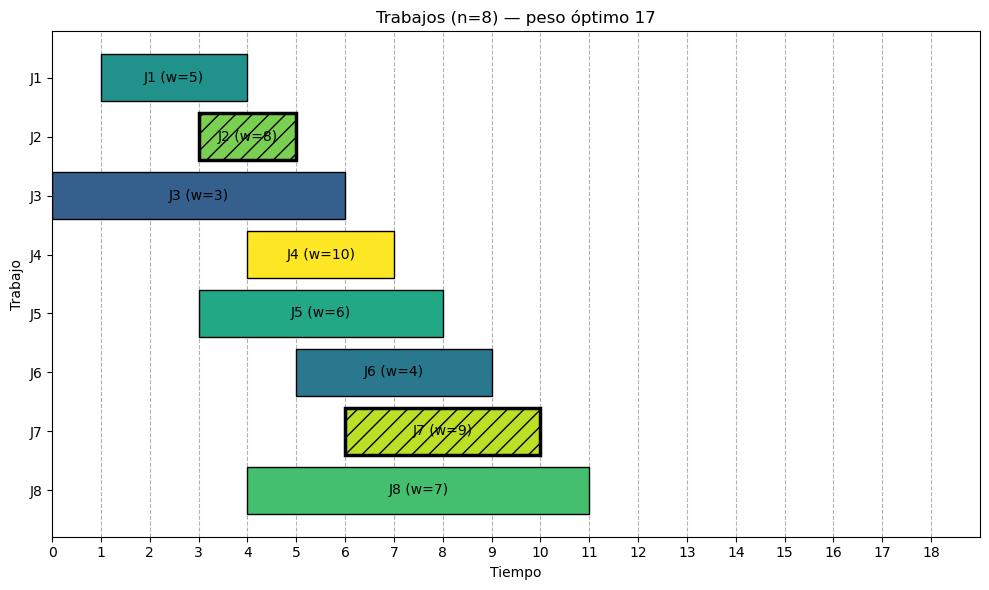

In [7]:
jobs = ujobs
best, chosen = bestSchedule(jobs)
print(f"peso óptimo {best} usando {chosen}")
print("p =", computeP(jobs))
plotJobs(jobs, chosen)

## Árbol de recursión

Naranja = subproblema que se calcula más de una vez.

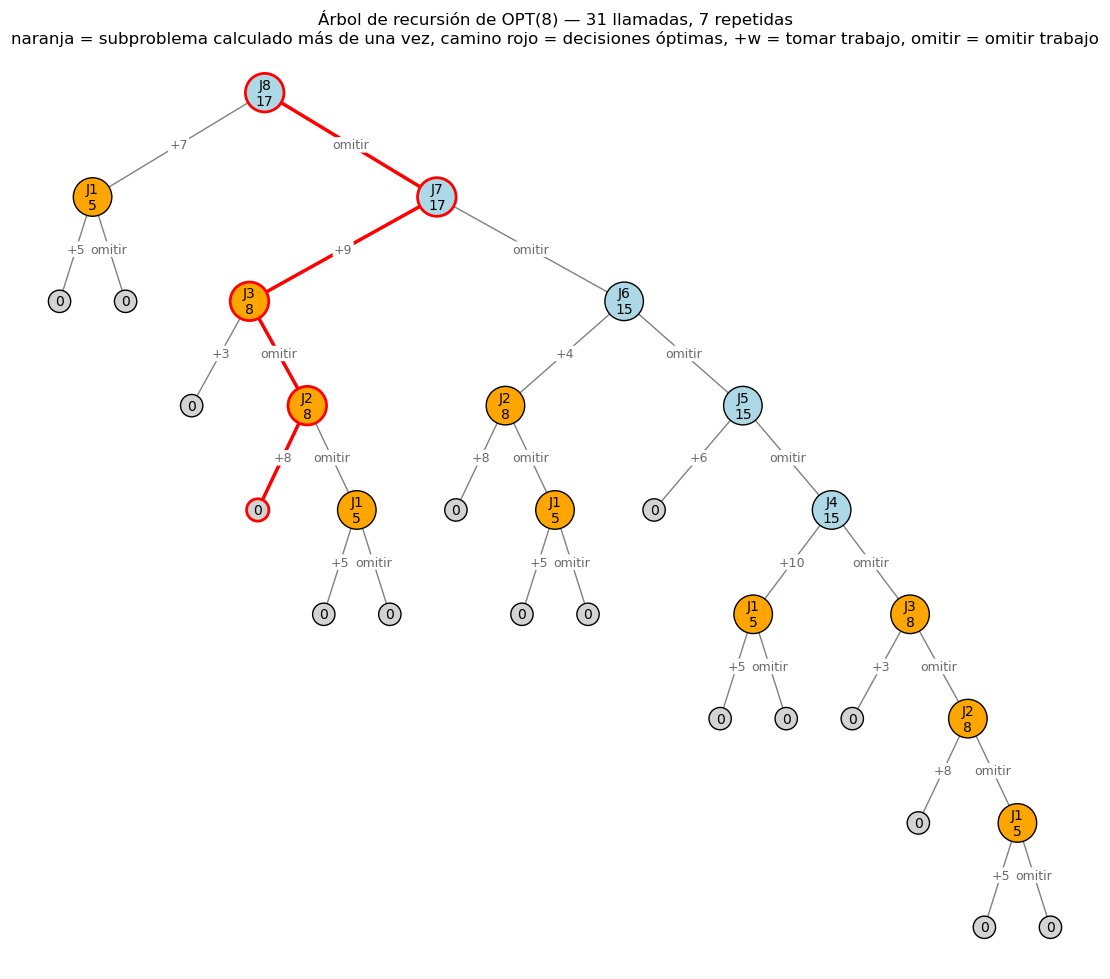

In [8]:
plotJobTree(buildJobTree(jobs))

## Fuerza bruta vs memoizado

In [9]:
p = computeP(jobs)
for label, (value, calls, _) in (("fuerza bruta", runBruteForce(jobs, p)), ("memoizado", runMemoized(jobs, p))):
    print(f"OPT({len(jobs)}) {label}: {value} en {calls} llamadas")

OPT(8) fuerza bruta: 17 en 31 llamadas
OPT(8) memoizado: 17 en 17 llamadas


    n |  llam. bruta tiempo bruta | llam. memo tiem. memo | aceleración
------------------------------------------------------------------------
    5 |           19       0.00ms |         11    0.002ms |        1x
   10 |          153       0.02ms |         21    0.002ms |        7x
   15 |          321       0.03ms |         31    0.003ms |       10x
   20 |        1,801       0.18ms |         41    0.004ms |       42x
   25 |       13,339       1.36ms |         51    0.005ms |      278x
   30 |       50,771       5.41ms |         61    0.005ms |     1007x
   35 |      433,327      41.44ms |         71    0.007ms |     5991x
   40 |            —    muy lento |         81    0.008ms | 
   60 |            —    muy lento |        121    0.011ms | 
   80 |            —    muy lento |        161    0.015ms | 
  100 |            —    muy lento |        201    0.074ms | 
  200 |            —    muy lento |        401    0.043ms | 
  500 |            —    muy lento |      1,001    0.109ms | 

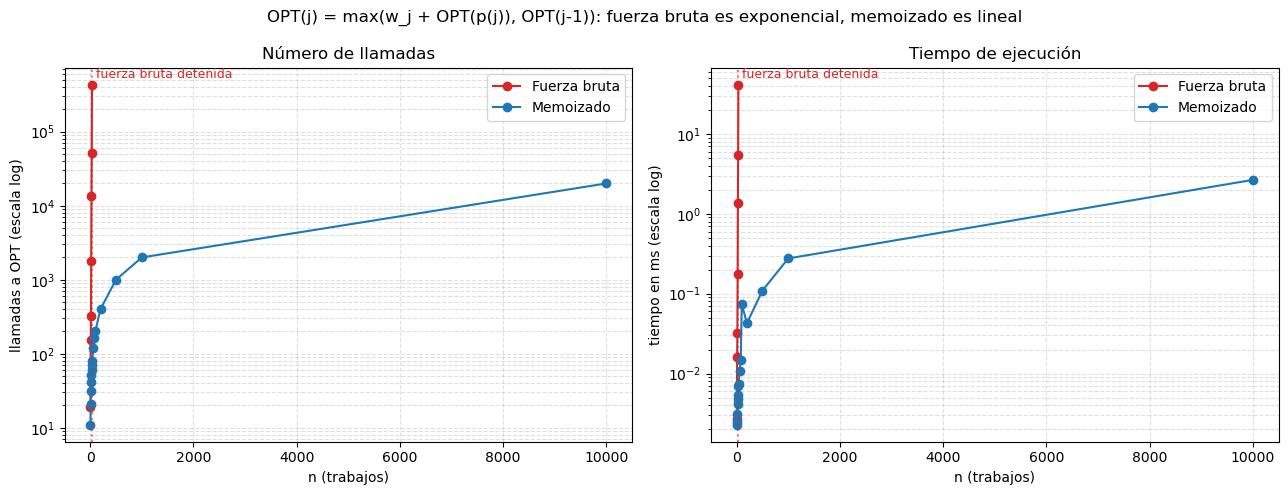

In [10]:
rows = compare(list(range(5, 41, 5)) + [60, 80, 100, 200, 500, 1000,10000], seed=0)
printTable(rows)
plotComparison(rows)

## Casos aleatorios

La fuerza bruta no se puede correr para estos tamaños, así que se estima: sus llamadas son exactas con T(j) = 1 + T(p(j)) + T(j−1), y se multiplican por el tiempo por llamada medido en un caso chico.

n=     10: peso óptimo 35 con 5 trabajos en 0.0ms | fuerza bruta esperada: 143 llamadas ≈ 0.014 ms


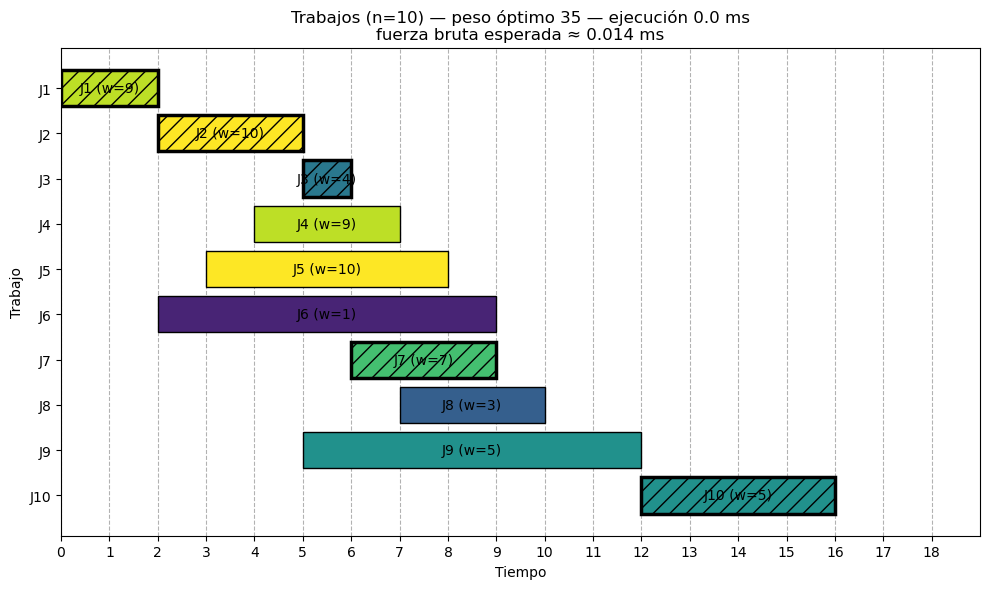

n=    100: peso óptimo 215 con 32 trabajos en 0.0ms | fuerza bruta esperada: 1.3×10^15 llamadas ≈ 1,461.3 días


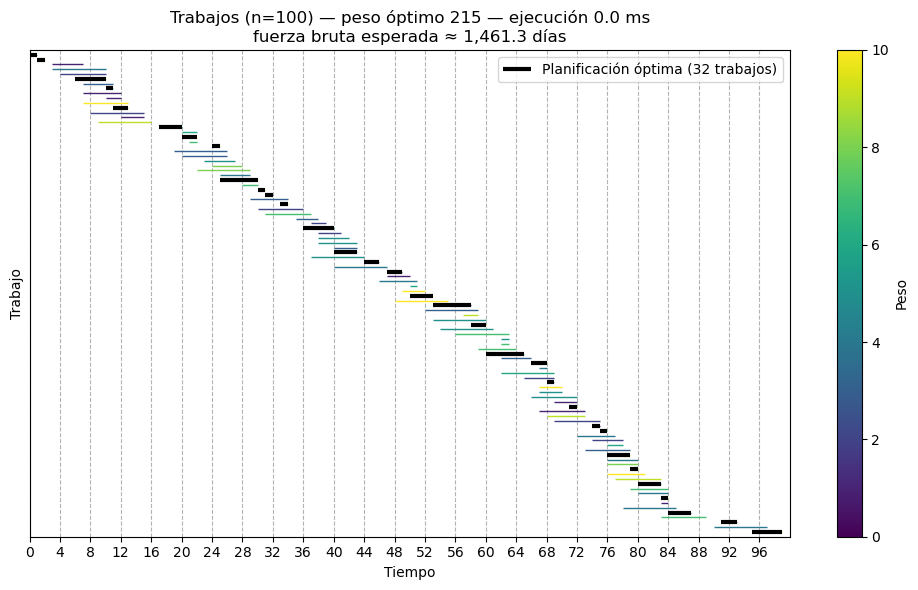

n=  1,000: peso óptimo 1,953 con 278 trabajos en 0.3ms | fuerza bruta esperada: 9.1×10^143 llamadas ≈ 1.0×10^132 días


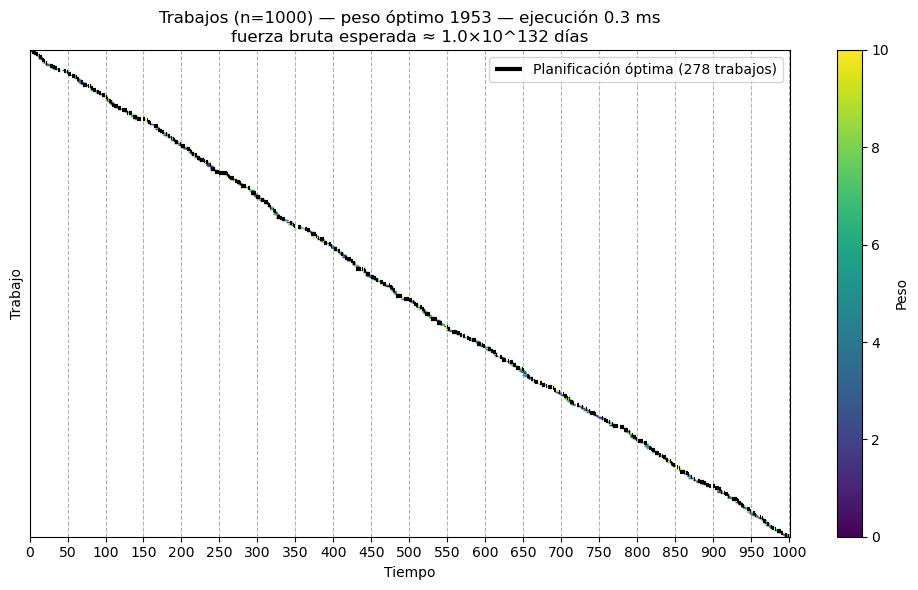

n= 10,000: peso óptimo 19,609 con 2,805 trabajos en 3.0ms | fuerza bruta esperada: 1.1×10^1444 llamadas ≈ 1.3×10^1432 días


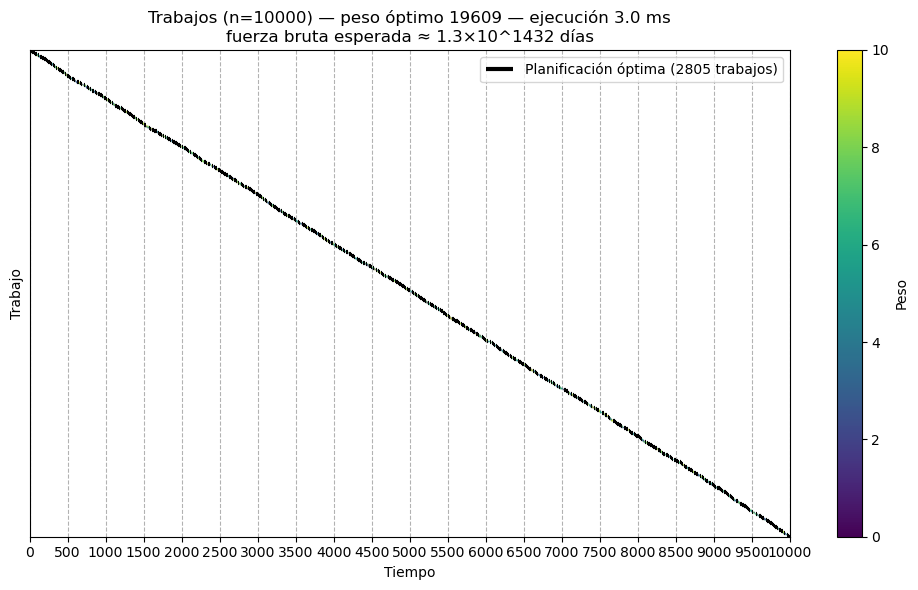

n=100,000: peso óptimo 197,978 con 28,231 trabajos en 66.7ms | fuerza bruta esperada: 3.0×10^14480 llamadas ≈ 3.4×10^14468 días


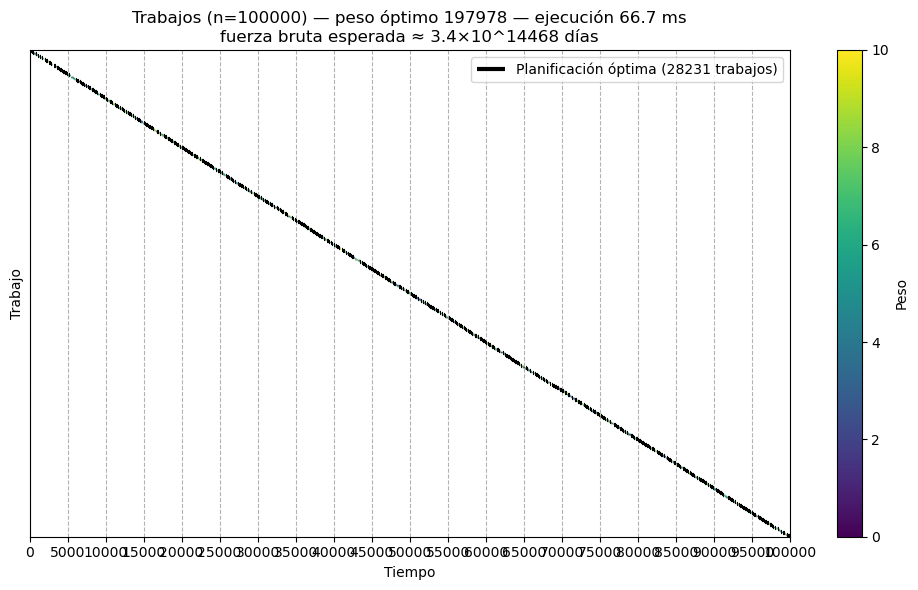

In [11]:
# Tiempo por llamada de la fuerza bruta, medido con un caso chico
sample = generateJobs(n=25, max_time=25, seed=0)
_, sample_calls, sample_seconds = runBruteForce(sample, computeP(sample))
ms_per_call = sample_seconds * 1000 / sample_calls

for n in (10, 100, 1000, 10_000, 100_000):
    random_jobs = generateJobs(n=n, max_time=max(18, n))
    t0 = time.perf_counter()
    best, chosen = bestSchedule(random_jobs)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    brute_log10 = math.log10(bruteForceCalls(computeP(random_jobs)))
    expected_brute = formatDuration(brute_log10 + math.log10(ms_per_call))
    print(f"n={n:>7,}: peso óptimo {best:,} con {len(chosen):,} trabajos en {elapsed_ms:.1f}ms"
          f" | fuerza bruta esperada: {formatLog10(brute_log10, 0)} llamadas ≈ {expected_brute}")
    plotJobs(random_jobs, chosen, elapsed_ms=elapsed_ms, expected_brute=expected_brute)